# DS4: Image Thresholding using CUDA
**Dataset:** MNIST Handwritten Digits Dataset


## Objective
Implement image thresholding using CUDA and compare CPU and GPU execution time.


In [ ]:
# Install required libraries
!pip install -q numba tensorflow matplotlib numpy


## Import Libraries


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from tensorflow.keras.datasets import mnist
from numba import cuda


## Check CUDA Availability


In [ ]:
print('CUDA Available:', cuda.is_available())

CUDA Available: True


## Load MNIST Dataset


In [ ]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()
print('Train Shape:',x_train.shape)
print('Test Shape:',x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train Shape: (60000, 28, 28)
Test Shape: (10000, 28, 28)


## Select and Enlarge an Image


Large Image Shape: (2800, 2800)


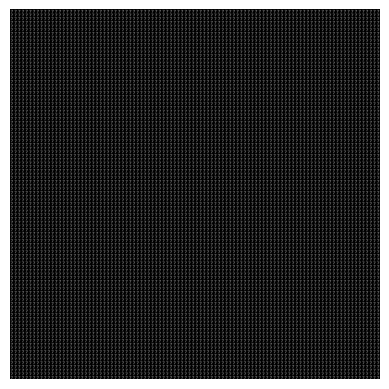

In [ ]:
img=x_test[0]
large_img=np.tile(img,(100,100)).astype(np.uint8)
print('Large Image Shape:',large_img.shape)
plt.imshow(large_img,cmap='gray')
plt.axis('off')
plt.show()


## CPU Thresholding


In [ ]:
def cpu_threshold(image,t=128):
    return np.where(image>t,255,0).astype(np.uint8)

start=time.time()
cpu_result=cpu_threshold(large_img)
cpu_time=(time.time()-start)*1000
print(f'CPU Time: {cpu_time:.3f} ms')


CPU Time: 43.317 ms


## CUDA Kernel


In [ ]:
@cuda.jit
def threshold_kernel(inp,out,t):
    r,c=cuda.grid(2)
    if r<inp.shape[0] and c<inp.shape[1]:
        out[r,c]=255 if inp[r,c]>t else 0


## GPU Thresholding


In [ ]:
d_in=cuda.to_device(large_img)
d_out=cuda.device_array_like(large_img)
threads=(16,16)
blocks=((large_img.shape[0]+15)//16,(large_img.shape[1]+15)//16)

# warmup run
threshold_kernel[blocks,threads](d_in,d_out,128)
cuda.synchronize()

start=time.time()
threshold_kernel[blocks,threads](d_in,d_out,128)
cuda.synchronize()
gpu_time=(time.time()-start)*1000
gpu_result=d_out.copy_to_host()
print(f'GPU Time: {gpu_time:.3f} ms')


GPU Time: 1.099 ms


## Compare Results


In [ ]:
print('Outputs Match:',np.array_equal(cpu_result,gpu_result))
print(f'Speedup: {cpu_time/gpu_time:.2f}x')


Outputs Match: True
Speedup: 39.43x


## Visualization


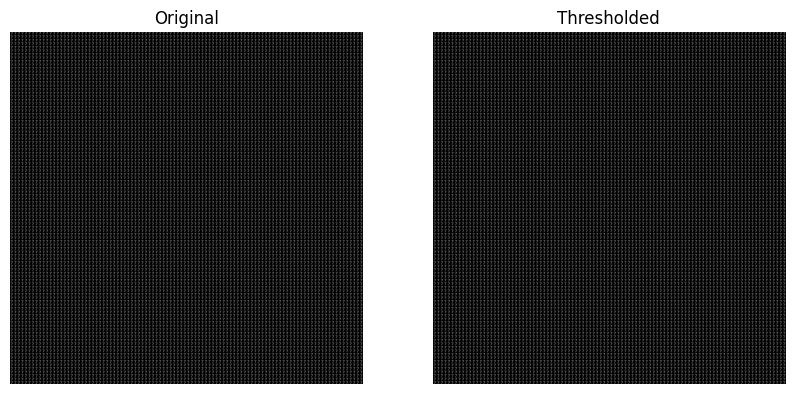

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(large_img,cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')
ax[1].imshow(gpu_result,cmap='gray')
ax[1].set_title('Thresholded')
ax[1].axis('off')
plt.show()


## CPU vs GPU Timing Graph


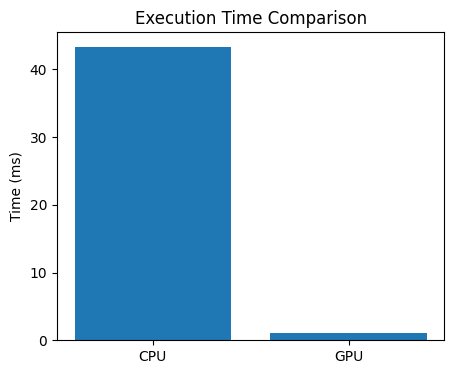

In [ ]:
plt.figure(figsize=(5,4))
plt.bar(['CPU','GPU'],[cpu_time,gpu_time])
plt.ylabel('Time (ms)')
plt.title('Execution Time Comparison')
plt.show()


## Conclusion
CUDA thresholding was implemented successfully on the MNIST dataset and compared against CPU execution.


# Additional Visualization and Analysis
The original thresholding experiment is preserved. The following section improves visualization so the thresholding effect is easier to observe.


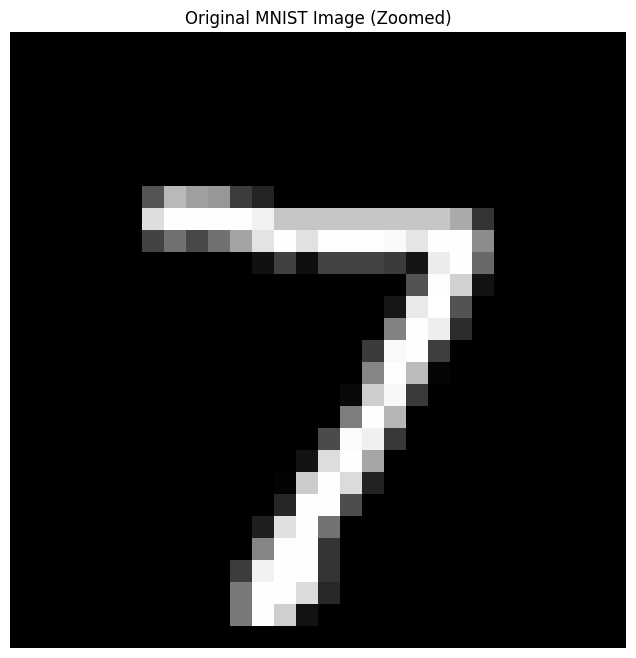

In [ ]:
# Display original image with larger size
plt.figure(figsize=(8,8))
plt.imshow(img,cmap='gray',vmin=0,vmax=255)
plt.title('Original MNIST Image (Zoomed)')
plt.axis('off')
plt.show()


In [ ]:
# Use nearest-neighbour scaling instead of tiling for visualization
zoom_factor=20
zoomed_original=np.repeat(np.repeat(img,zoom_factor,axis=0),zoom_factor,axis=1)
zoomed_threshold=np.repeat(np.repeat(gpu_result,zoom_factor,axis=0),zoom_factor,axis=1)

fig,ax=plt.subplots(1,2,figsize=(12,6))
ax[0].imshow(zoomed_original,cmap='gray',vmin=0,vmax=255)
ax[0].set_title('Zoomed Original')
ax[0].axis('off')

ax[1].imshow(zoomed_threshold,cmap='gray',vmin=0,vmax=255)
ax[1].set_title('Zoomed Thresholded')
ax[1].axis('off')

plt.show()


In [ ]:
# Difference image highlights changed pixels
difference=np.abs(img.astype(np.int16)-gpu_result.astype(np.int16))

plt.figure(figsize=(6,6))
plt.imshow(difference,cmap='hot')
plt.title('Difference Between Original and Thresholded')
plt.colorbar()
plt.axis('off')
plt.show()


In [ ]:
# Compare multiple threshold values
thresholds=[50,100,150,200]

fig,ax=plt.subplots(1,4,figsize=(16,4))

for i,t in enumerate(thresholds):
    out=np.where(img>t,255,0)
    ax[i].imshow(out,cmap='gray')
    ax[i].set_title(f'T={t}')
    ax[i].axis('off')

plt.show()


In [ ]:
# Pixel statistics
changed_pixels=np.sum(img!=gpu_result)
total_pixels=img.size
percentage=(changed_pixels/total_pixels)*100

print('Total Pixels       :',total_pixels)
print('Changed Pixels     :',changed_pixels)
print(f'Pixels Modified    : {percentage:.2f}%')


## Improved Result Analysis
MNIST images are only 28×28 pixels. Because the image is very small, the original and thresholded outputs may appear visually similar when displayed normally. The zoomed comparison, difference map, and multiple-threshold analysis make the effect much easier to observe.
